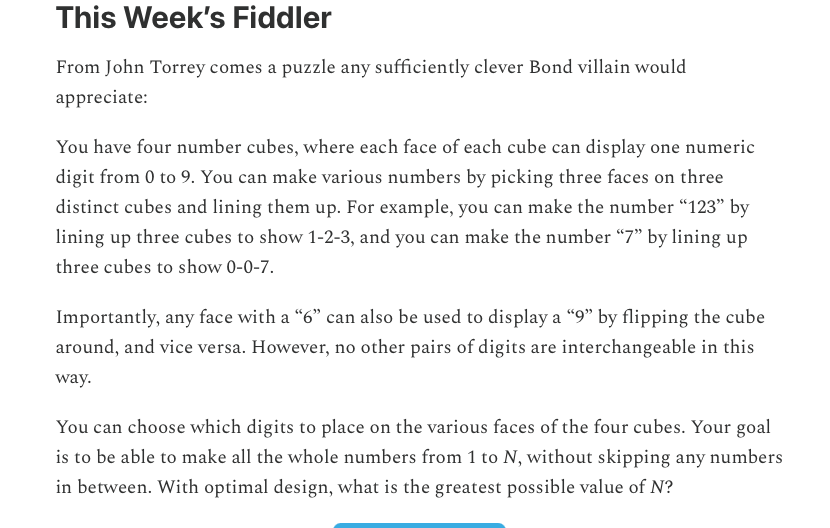

In [88]:
# Part one we can start by trying to brute force
num_reps = {i: {i} for i in range(10)}

num_reps[6].add(9)
num_reps[9].add(6)

NUM_CUBES = 4
CUBES_NEEDED = 3
# there are only really 9 digits we could place since 6 = 9.

# a cube having a repeat makes no sense.
# so cube 1 has 8 * 7 * 6 * 5 * 4 * 3


def can_make(cubes, N):
    """
    True if we can make N from the cubes
    """
    if N > int("9" * len(cubes)):
        return False
    goal_srt = str(N).zfill(CUBES_NEEDED)
    # we need there to be some combination of goal str such that
    # pick three cubes, can we make the goal number?
    # do like a recursive backtrack where we see if we can pick a given cube, if a number lies in it, we move to next cube and remove digits.

    used = []

    def check(idx):
        """Backtracking function, try to find a cube that has the digit we need"""
        if idx == CUBES_NEEDED:
            return True
        val = num_reps[int(goal_srt[idx])]
        for i in range(NUM_CUBES):
            if i in used:
                continue
            elif val & cubes[i]:
                used.append(i)
                if check(idx + 1):
                    return True
                used.pop()

        return False

    return check(0)


def max_score(dice_set):
    """For the given set of die, what is the max score we can get?"""
    cur_max = 1
    while can_make(dice_set, cur_max):
        cur_max += 1
    return cur_max - 1


# note we have an upper bound of 776.
# Since otherwise, we need to have 2 zeros, then 3 1's, 3, 2's ... 3, 7's  which is 23 elements but we need at least 2 8s to get past this. which we can't fit in.

# we can verifiably reach the bound so it is the optimal value.
dice1 = {0, 1, 4, 5, 6, 8}  # 8 choose 5
dice2 = {1, 2, 3, 5, 6, 8}
dice3 = {0, 2, 3, 4, 6, 7}  # 8 choose 5
dice4 = {1, 2, 3, 4, 5, 7}
all_die = [dice1, dice2, dice3, dice4]

max_val = max_score(all_die)
print(f"We can reach the upper bound of {max_val}")

We can reach the upper bound of 776


# Part 2
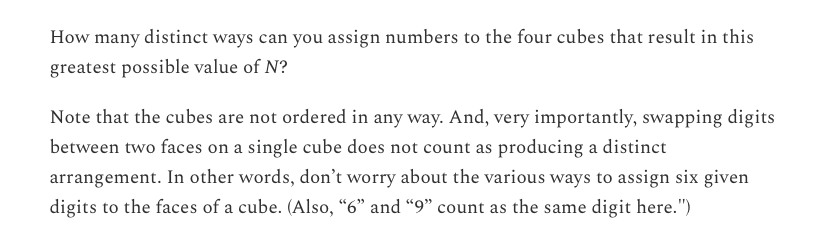

There should be like $\binom{8}{5}$ different choices for each die. Two of the die have a zero and the other two don't and there are only 9 total digits including (6 and 9 are the same here). There are no repeats on a die. We could hash die "types" then group good die combos by type counts so that we can properly weight them. 

We need to place numbers on our dice such that we match the counts and then verify that they can make the target number. 

In [89]:
from collections import defaultdict

# We could maybe find all these fast by backtracking.
# place the current digit in the 2/3 die where they could fit. continue, if good, hash the die types and counts

digits_w_2_cnt = [0, 7, 8]
arrangements = set()
dice = [[] for _ in range(NUM_CUBES)]


def solve(digit):
    if digit == 9:

        d_sets = [set(d) for d in dice]
        if max_score(d_sets) == max_val:
            # we are good, hash and store
            t = [tuple(dice[i]) for i in range(NUM_CUBES)]
            t.sort()
            arrangements.add(tuple(t))
        return

    elif digit in digits_w_2_cnt:
        # find two open lists place them and continue
        for i in range(NUM_CUBES):
            for j in range(i + 1, NUM_CUBES):
                if len(dice[i]) == 6 or len(dice[j]) == 6:
                    continue

                dice[i].append(digit)
                dice[j].append(digit)
                solve(digit + 1)
                dice[i].pop()
                dice[j].pop()

        pass
        # remove them.
    else:
        # find three open lists, place them and continue
        for i in range(NUM_CUBES):
            for j in range(i + 1, NUM_CUBES):
                for k in range(j + 1, NUM_CUBES):
                    if len(dice[i]) == 6 or len(dice[j]) == 6 or len(dice[k]) == 6:
                        continue
                    dice[i].append(digit)
                    dice[j].append(digit)
                    dice[k].append(digit)
                    # print(f"adding!, {dice}")
                    solve(digit + 1)
                    dice[i].pop()
                    dice[j].pop()
                    dice[k].pop()
    return


solve(0)
print(
    f' I found that there are {len(arrangements)} different "types" of dice combos that make our target"'
)

 I found that there are 855 different "types" of dice combos that make our target"
